In [15]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
import torch
from transformers import AutoTokenizer

from litgpt.pretrain import truncate_and_mask, extend_w_mask
from litgpt.mtp import interleaved_mtp_mask_mod_factory

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import yaml

# import orjson
import re
import ast

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'font.serif': ['Computer Modern'],
})

import re

def tex_safe(text):
    # This keeps your source 'text' original, but returns a 
    # version LaTeX won't choke on.
    return text.replace("%", r"\%")#.replace("_", r"\_")

# Ensure the ARM64 path is active in the environment
tex_bin = os.path.expanduser("~/texlive/bin/aarch64-linux")
if tex_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{tex_bin}:{os.environ['PATH']}"

# Use the absolute path to run tlmgr
!tlmgr install fontext
!tlmgr install cm-super type1cm dvipng
!tlmgr install amsmath amsfonts symbol listings xcolor
!{tex_bin}/tlmgr install underscore geometry graphics
!{tex_bin}/texhash

tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package fontext not present in repository.
tlmgr: action install returned an error; continuing.
tlmgr: An error has occurred. See above messages. Exiting.
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: cm-super
tlmgr install: package already present: dvipng
tlmgr install: package already present: type1cm
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: amsfonts
tlmgr install: package already present: amsmath
tlmgr install: package already present: listings
tlmgr install: package already present: symbol
tlmgr install: package already present: xcolor
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: geometry
tlmgr install: package already present: g

In [3]:
%autoreload 2
from attn_gym import visualize_attention_scores

In [4]:
BASE_FIGURE_DIR = f"{os.getcwd()}/auto_figures"

In [5]:
tokenizer = AutoTokenizer.from_pretrained("/capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/checkpoints/extended/Magpie-Align/Llama-3.1-8B-Magpie-Align-SFT-v0.1-MTPV128384")
MASK_ID = 128259
# EOS_ID = 128001
EOS_ID = 128009

The tokenizer you are loading from '/capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/checkpoints/extended/Magpie-Align/Llama-3.1-8B-Magpie-Align-SFT-v0.1-MTPV128384' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


In [55]:
BDA = False
Ofs = 0
# Ofs = -2

TRUNCATION_LENGTH = S = 18
mask_region_ct = 3
k_toks = 3
# TRUNCATION_LENGTH = S = 12
# mask_region_ct = 2
# k_toks = 3
k_toks = 5

K = k_toks - 1
P = (S // mask_region_ct) - K
assert P > 0, "P must be positive, else we have no real input tokens to attend to."

B=1
n_query_groups = 8

H = 8

In [ ]:
def make_tensor():
    return torch.ones(B, n_query_groups, S, H, device="cpu")
# viz_name = f"mtp_mask_visual_P{P}_K{K}_S{S}_O{Ofs}_B{B}_H{H}_bda{BDA}"
viz_name = f"MTP_block_mask_with_Seq_Len={S}_Prefix={P}_k={K+1}_Offset={Ofs}"
os.makedirs(BASE_FIGURE_DIR, exist_ok=True)
visualize_attention_scores(
    make_tensor(), # query
    make_tensor(), # key
    mask_mod=interleaved_mtp_mask_mod_factory(P, K, Ofs, bidirect_ss_attn=BDA),
    device="cpu",
    name=viz_name,
    path=Path(f"{BASE_FIGURE_DIR}/{viz_name}"),
)

In [56]:
# B, S, F = cos.shape 
# P = self.P
# K = self.K
region_width = P + K
offset = Ofs

assert abs(offset) < P, "Offset magnitude must be less than prefix length P."

source_block_starts = torch.arange(0, S, P) 

base_range = torch.arange(region_width)#, device=cos.device)

num_blocks = (S + P - 1) // P

block_starts = torch.arange(0, num_blocks * P, P).unsqueeze(1) 

full_indices = block_starts + base_range

full_indices = full_indices.flatten()

final_indices = full_indices[:S]

# not clear we need this next clamp actually.
final_indices = torch.clamp(final_indices, max=S - 1)

# special roll slide thing for offset
if offset < 0:
    if K == 0:
        # we need to simulate one extra index because indexing with -0 will be the first element
        # which is wrong. we want the last + 1 element in this special case
        old_final_mask_start_pos = final_indices[-1] + 1
    else:
        old_final_mask_start_pos = final_indices[-K]
    final_indices = final_indices.roll(offset)
    final_indices[offset:] = torch.arange(old_final_mask_start_pos, old_final_mask_start_pos + (-offset), device=cos.device)
    final_indices += offset  # shift all indices by offset amount
elif offset > 0:
    final_indices = final_indices.roll(offset)
    final_indices[0:offset] = torch.arange(-offset, 0, device=cos.device)
    final_indices += offset  # shift all indices by offset amount

final_indices = final_indices.cpu().tolist()
print(f"Shifted position indices for block rope feats: {final_indices}")

Shifted position indices for block rope feats: [0, 1, 2, 3, 4, 5, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9]


In [89]:
# TRAIN_TEXT = """\
# <|begin_of_text|><|start_header_id|>user<|end_header_id|>Sue works in a factory and every 30 minutes, a machine she oversees produces 30 cans of soda. How many cans of soda can x machine produce in 8 hours?
# If we know the answer to the above question is 480, what is the value of unknown variable x?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

# We know that every 30 minutes, a machine produces 30 cans of soda.
# Since there are 60 minutes in an hour, and 8 hours in total, the total number of minutes is 60 * 8 = 480 minutes.
# If a machine produces 30 cans of soda every 30 minutes, then in 480 minutes, it will produce (480/30) * 30 = 480 cans of soda.
# We are given that the total number of cans of soda produced is 480, so we can write: 480 = 480 * x.
# Dividing both sides by 480, we get: x = 1.
# The value of x is 1.
# #### 1
# The answer is: 1<|eot_id|>
# """
# TRAIN_TEXT = """\
# Dividing both sides by 480, we get: x = 1.
# The value of x is 1.
# #### 1
# The answer is: 1<|eot_id|>
# """
TRAIN_TEXT = """\
the total number of minutes is 60 * 8 = 480 minutes.
"""

input_ids = tokenizer(TRAIN_TEXT, add_special_tokens=False,return_tensors="pt").input_ids
input_ids = input_ids[:, 0 : TRUNCATION_LENGTH].contiguous().long()
target_ids = input_ids[:, 1 : (TRUNCATION_LENGTH + 1)].contiguous().long()

print("Input IDs:", input_ids)
print("Target IDs:", target_ids)

Input IDs: tensor([[ 1820,  2860,  1396,   315,  4520,   374,   220,  1399,   353,   220,
            23,   284,   220, 11738,  4520,   627]])
Target IDs: tensor([[ 2860,  1396,   315,  4520,   374,   220,  1399,   353,   220,    23,
           284,   220, 11738,  4520,   627]])


In [90]:
# extend_w_mask(input_ids, k_toks, mask_id=MASK_ID)
extend_w_mask(input_ids, k_toks, min_mask_id=MASK_ID, max_mask_id=MASK_ID+3)

tensor([[  1820,   2860,   1396,    315,   4520,    374,    220,   1399,    353,
            220,     23,    284,    220,  11738,   4520,    627, 128259, 128260,
         128261, 128262]])

In [91]:
# input_ids, target_ids, mask_id_mask, pred_pos_mask, prefix_pos_mask = truncate_and_mask(input_ids=input_ids, target_ids=target_ids, k_toks=k_toks, mask_id=MASK_ID, truncation_length=TRUNCATION_LENGTH, mask_region_ct=mask_region_ct, offset=Ofs, pad_token_id=EOS_ID)
input_ids, target_ids, mask_id_mask, pred_pos_mask, prefix_pos_mask = truncate_and_mask(input_ids=input_ids, target_ids=target_ids, k_toks=k_toks, min_mask_id=MASK_ID, max_mask_id=MASK_ID+3, truncation_length=TRUNCATION_LENGTH, mask_region_ct=mask_region_ct, offset=Ofs, pad_token_id=EOS_ID)

print("Masked Input IDs:", input_ids)
print("Target IDs after masking:", target_ids)
print("Mask ID Mask:", mask_id_mask)
print("Prediction Position Mask:", pred_pos_mask)
print("Prefix Position Mask:", prefix_pos_mask)

Masked Input IDs: tensor([[  1820,   2860, 128259, 128260, 128261, 128262,   1396,    315, 128259,
         128260, 128261, 128262,   4520,    374, 128259, 128260, 128261, 128262]])
Target IDs after masking: tensor([[2860, 1396,  315, 4520,  374,  220,  315, 4520,  374,  220, 1399,  353,
          374,  220, 1399,  353,  220,   23]])
Mask ID Mask: tensor([[False, False,  True,  True,  True,  True, False, False,  True,  True,
          True,  True, False, False,  True,  True,  True,  True]])
Prediction Position Mask: tensor([[False,  True,  True,  True,  True,  True, False,  True,  True,  True,
          True,  True, False,  True,  True,  True,  True,  True]])
Prefix Position Mask: tensor([[ True, False, False, False, False, False,  True, False, False, False,
         False, False,  True, False, False, False, False, False]])


In [49]:
len(input_ids[0])

18

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Hardcoded mapping for Llama-3.1-8B-Magpie-Align-SFT-v0.1-MTPV128384
SHORT_NAMES = {
    "<|begin_of_text|>": "<BOS>",
    "<|start_header_id|>": "<H_ST>",
    "<|end_header_id|>": "<H_EN>",
    "<|eot_id|>": "<EOT>",
    "<|end_of_text|>": "<EOS>",
    "<|mtp_special_token_0|>": "<MTP>",
}

def visualize_prepared_input_v2(
    input_ids, 
    target_ids,
    mask_id_mask, 
    pred_pos_mask, 
    prefix_pos_mask, 
    position_ids,
    tokenizer, 
    show_position_ids=True,
    show_mask_mask=True,
    show_prefix_mask=True,
    tokens_per_row=10, 
    fig_size=(16, 12),
    save_fig = False,
    figname = "example_tok_masking_viz",
    fontsize = 10,
):
    """
    Generates a 6-row visual with prettified special tokens, including Target IDs.
    """
    # Flatten tensors to lists
    ids = input_ids.flatten().tolist()
    t_ids = target_ids.flatten().tolist()
    m_mask = mask_id_mask.flatten().tolist()
    p_mask = pred_pos_mask.flatten().tolist()
    pre_mask = prefix_pos_mask.flatten().tolist()
    pos_ids = position_ids if show_position_ids else None
    
    num_tokens = len(ids)
    num_rows = (num_tokens + tokens_per_row - 1) // tokens_per_row
    
    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_xlim(0, 100)
    # Adjusted Y-limit for 6 rows per block
    ax.set_ylim(-16 * num_rows, 5)
    ax.axis('off')

    col_width = 100 / (tokens_per_row + 1)
    row_spacing = 2.0
    block_spacing = 17 
    
    for i in range(num_tokens):
        row_idx = i // tokens_per_row
        col_idx = i % tokens_per_row
        
        x = col_idx * col_width + 8 
        y = -(row_idx * block_spacing)
        
        # Decode and Prettify
        token_text = tokenizer.decode([ids[i]]).replace("\n", "↵")
        for full, short in SHORT_NAMES.items():
            token_text = token_text.replace(full, short)
        
        row_data = [
            (pos_ids[i], "#f3e5f5" if show_position_ids else None) if show_position_ids else (),
            (token_text, "#e1f5fe"),             # Row 1: Token Text
            (str(ids[i]), "#fff3e0"),            # Row 2: Input ID
            (str(t_ids[i]), "#f1f8e9"),           # Row 3: Target ID
            # (str(int(m_mask[i])), "#cfd8dc"),    # Row 4: Mask ID Mask
            (str(int(p_mask[i])), "#e8f5e9" if p_mask[i] else "#fce4ec"), # Row 5: Pred Mask
            # (str(int(pre_mask[i])), "#f3e5f5")    # Row 6: Prefix Mask
        ]
        if show_mask_mask:
            row_data.insert(3 + (1 if show_position_ids else 0), (str(int(m_mask[i])), "#cfd8dc"))  # Row 4: Mask ID Mask
        if show_prefix_mask:
            row_data.append((str(int(pre_mask[i])), "#f3e5f5"))  # Row 6: Prefix Mask
        
        if show_position_ids:
            labels = ["PosID:"]
        else:
            labels = []

        # labels = ["Text:", "InpID:", "TgtID:", "Mask:", "Pred:"]#, "Pref:"]
        labels += ["Text:", "InpID:", "TgtID:", "Pred:"]#, "Pref:"]
        if show_mask_mask:
            labels.insert(3 + (1 if show_position_ids else 0), "Mask:")
        if show_prefix_mask:
            labels.append("Pref:")
        
        for r_idx, (val, color) in enumerate(row_data):
            curr_y = y - (r_idx * row_spacing)
            
            if col_idx == 0:
                ax.text(x - 2.5, curr_y, labels[r_idx], va='center', ha='right', 
                        fontsize=fontsize+1, family='monospace', fontweight='bold', color='#455a64')

            edge_col = '#cfd8dc'
            line_w = 0.5

            rect = patches.Rectangle(
                (x - col_width/2.2, curr_y - 0.8), col_width * 0.9, 1.6,
                linewidth=line_w, edgecolor=edge_col, facecolor=color, zorder=2
            )
            ax.add_patch(rect)
            
            ax.text(x, curr_y, val, va='center', ha='center', 
                    fontsize=fontsize, family='monospace', fontweight='bold', zorder=3)

    plt.tight_layout()

    if save_fig:
        output_path = f"{BASE_FIGURE_DIR}/{figname}"
        print(f"Figure saving to {output_path}.png and .pdf")
        plt.savefig(f"{output_path}.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.savefig(f"{output_path}.pdf", bbox_inches='tight')
        

    return fig

In [51]:
SAVE_FIG = False
# SAVE_FIG = True

INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
I

INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
I

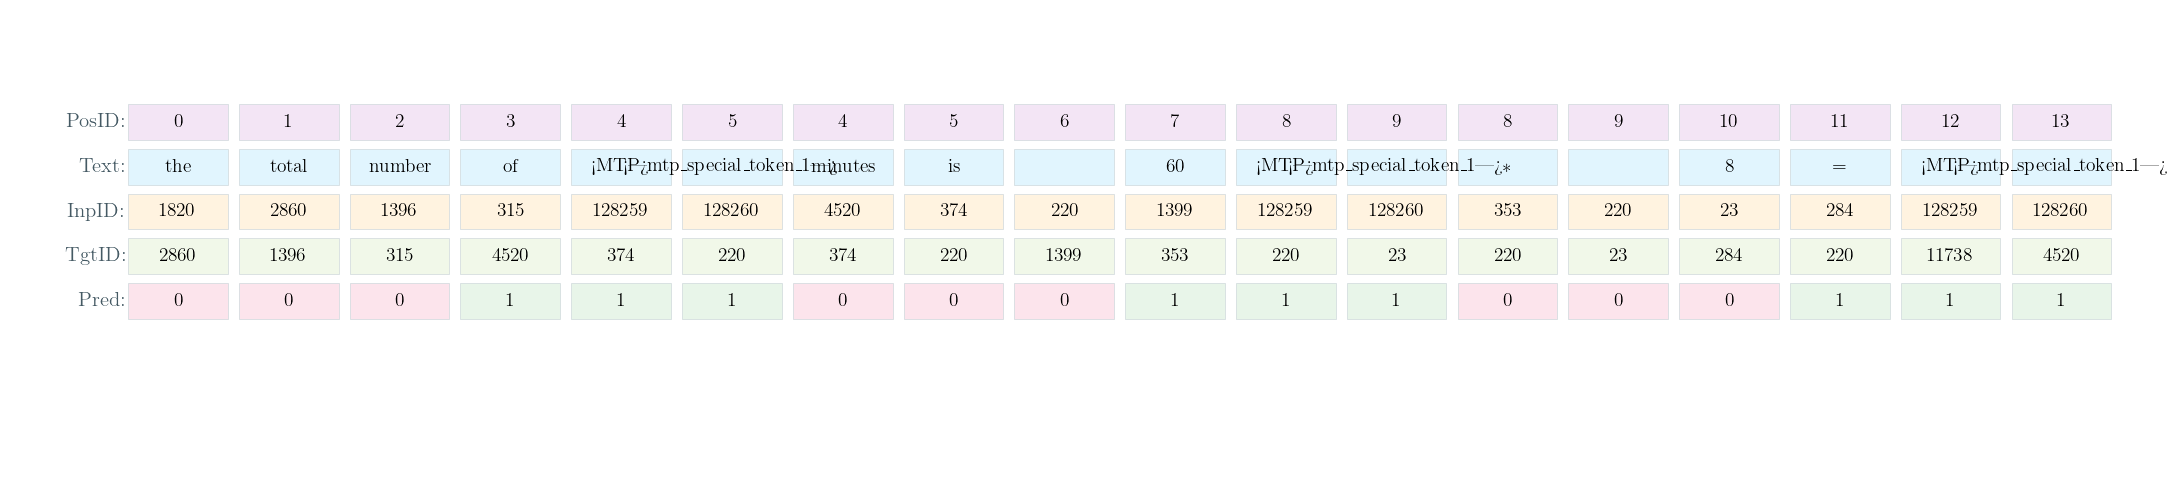

In [52]:

fig = visualize_prepared_input_v2(
    input_ids=input_ids, 
    target_ids=target_ids,
    mask_id_mask=mask_id_mask, 
    pred_pos_mask=pred_pos_mask, 
    prefix_pos_mask=prefix_pos_mask, 
    position_ids = final_indices,
    tokenizer=tokenizer, 
    show_position_ids=True,
    show_mask_mask=False,
    show_prefix_mask=False,
    tokens_per_row=len(input_ids[0]), 
    fig_size=(22, 5),
    fontsize=14,
    save_fig=SAVE_FIG,
)
plt.show()